In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import matthews_corrcoef, precision_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold, TimeSeriesSplit
from xgboost import XGBClassifier
import pickle
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

def get_data(ticker):
    
    df_orig = yf.Ticker(ticker).history(period="max", interval="1d", auto_adjust=True).reset_index()[['Date', 'Close', 'High', 'Low', 'Volume']]
    df_orig['Date'] = pd.to_datetime(df_orig['Date']).dt.strftime('%Y-%m-%d')
    
    return df_orig

def ma_features(df): 
    
    df = df.sort_values(by='Date', ascending=True)

    # =======================
    # Basic SMAs and Ratios
    # =======================
    for window in [5, 10, 25, 50, 100, 200]:
        
        df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()

        # Current close relativet to n_day high | max 1
        df[f'Close_Rel_Max{window}'] = (df['Close'] / df['High'].rolling(window=window).max()).round(2)
        # Current close relativet to n_day low | min 1
        df[f'Close_Rel_Min{window}'] = (df['Close'] / df['Low'].rolling(window=window).min()).round(2)

        if window in (50, 100, 200):
            df[f'num_days_{window}'] = 0
    
    for window in [50, 100, 200]:
        for i in range(1, len(df)):
            prev = df.loc[i - 1, f'num_days_{window}']
            price = df.loc[i, 'Close']
            sma = df.loc[i, f'SMA_{window}']
            if price > sma:
                df.loc[i, f'num_days_{window}'] = prev + 1 if prev >= 0 else 0
            elif price < sma:
                df.loc[i, f'num_days_{window}'] = prev - 1 if prev <= 0 else 0
            else:
                df.loc[i, f'num_days_{window}'] = 0

        #df[f'num_days_{window}'] = df[f'num_days_{window}'].apply(lambda x: int(5 * round(x / 5)))

    lag_periods = []#[50, 100, 150, 200]

    for lag in lag_periods:
        new_cols = {}
        for col in df.columns:
            if col.startswith('SMA_'):
                new_cols[f'{col}_Lag{lag}'] = (df[col] / df[col].shift(-lag)).round(2)

        df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
            
    for window in []: #[50, 100, 200]:
        for i in range(1, len(df)):
            prev = df.loc[i - 1, f'num_days_{window}']
            price = df.loc[i, 'Close']
            sma = df.loc[i, f'SMA_{window}']
            if price > sma:
                df.loc[i, f'num_days_{window}'] = prev + 1 if prev >= 0 else 0
            elif price < sma:
                df.loc[i, f'num_days_{window}'] = prev - 1 if prev <= 0 else 0
            else:
                df.loc[i, f'num_days_{window}'] = 0

        #df[f'num_days_{window}'] = df[f'num_days_{window}'].apply(lambda x: int(5 * round(x / 5)))

    # ============================
    # Relative Position Features
    # ============================
    def rows_since_max(x): return len(x) - x.argmax() - 1
    def rows_since_min(x): return len(x) - x.argmin() - 1

    for window in [10, 30, 60, 120, 240]:

        df[f'Rel_Max_{window}'] = (df['High'] / df['High'].rolling(window=window).max()).round(2)
        df[f'Rel_Min_{window}'] = (df['Low'] / df['Low'].rolling(window=window).min()).round(2)
        df[f'Max_{window}_Rows_Since'] = df['High'].rolling(window=window).apply(rows_since_max, raw=True)
        df[f'Min_{window}_Rows_Since'] = df['Low'].rolling(window=window).apply(rows_since_min, raw=True)

    for a, b in [(50, 100), (50, 200), (100, 200), (10, 25), (10, 50), (10, 100), (10, 200), (25, 50), (25, 100), (25, 200),
                (5, 10), (5, 25), (5,50)]:    
        df[f'{a}_SMA_{b}'] = (df[f'SMA_{a}'] / df[f'SMA_{b}']).round(2)

    def round_to_nearest_point05(x):
        return round(x * 20) / 20

    for window in [5, 10, 25, 50, 100, 200]:

        df[f'SMA_{window}'] = (df['Close'] / df[f'SMA_{window}']).round(2)
        #df[f'EMA_{window}'] = (df['Close'] / df[f'EMA_{window}']).round(2)

    return df

def rsi_features(df):

    df = df.sort_values(by='Date', ascending=True)

    # RSI
    def RSI(data, period, diff):
        delta = data['Close'].diff(diff)
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        RS = gain / loss
        return (100 - (100 / (1 + RS))).round(0)

    difs = [1, 3, 5]
    for dif in difs:
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)

    return df

def generate_returns(df, returns):

    def add_column_based_on_future_value(df, days):

        df = df.sort_values(by='Date', ascending=True)
        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']
        df[f'Return%_{days}'] = (future_return * 100).round(1) 
        df[f'Return_{days}'] = (future_return > 0).astype(int)
        
        past_return = (df['Close'] - df['Close'].shift(days)) / df['Close']
        df[f'Past_Return_{days}'] = (past_return > 0).astype(int)

        return df

    df_returns = df.copy()

    for r in returns:
    
        df_returns = add_column_based_on_future_value(df_returns, r)

    return df_returns


In [2]:
ticker = 'QQQ'
df_orig = get_data(ticker)
df_feats = ma_features(df_orig)
returns = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 40, 50]
df_returns = generate_returns(df_orig, returns)
df_merged = pd.merge(df_feats, df_returns[[col for col in df_returns.columns if col.startswith('Return')] + ['Date']], on='Date')

# Challenger - Incumbent Logic

Run 1 of 5 | LB: 9 | 2025-09-18 - 2025-10-21
Run 2 of 5 | LB: 9 | 2025-08-25 - 2025-09-23
Run 3 of 5 | LB: 9 | 2025-07-25 - 2025-08-25
Run 4 of 5 | LB: 9 | 2025-06-25 - 2025-07-28
Run 5 of 5 | LB: 9 | 2025-05-27 - 2025-06-27


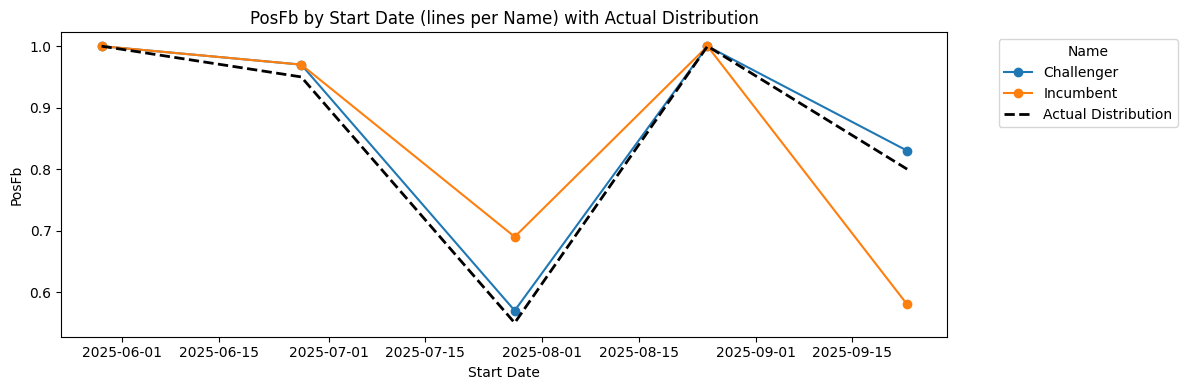

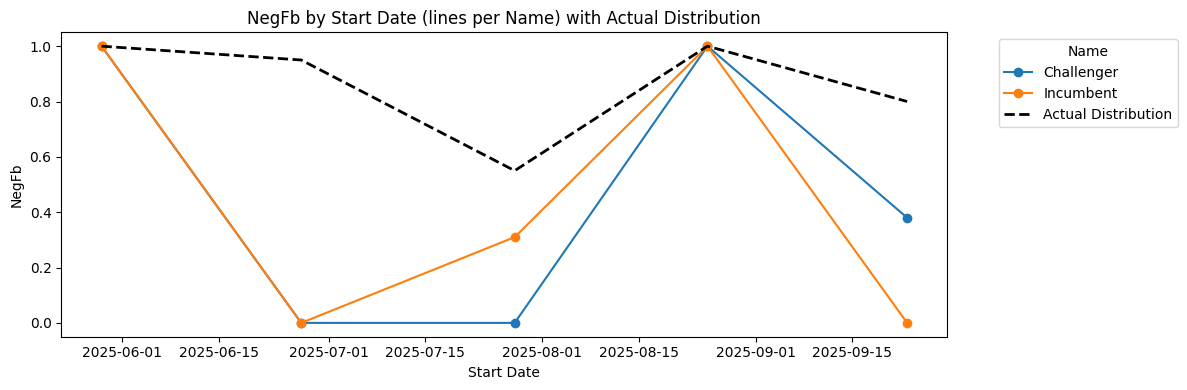

In [50]:
def perm_importance(all_perm_dfs):

    # Combine all permutation importance DataFrames
    current_perm_df = pd.concat(all_perm_dfs, ignore_index=True)

    # Apply the retention logic per group
    def apply_retention_logic(group):
        group = group.copy()
        group["drop_flag"] = group["importance_mean"] <= 0.01

        total = len(group)
        retained = (~group["drop_flag"]).sum()
        min_retained = int(np.ceil(total * 0.45))

        if retained < min_retained:
            top_feats = group.sort_values(by="importance_mean", ascending=False).head(min_retained)["feature"]
            group["drop_flag"] = ~group["feature"].isin(top_feats)

        return group

    # Apply group-wise adjustment by model_name, arch, horizon
    current_perm_df = current_perm_df.apply(apply_retention_logic)
    
    return current_perm_df

def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            i = 1
            #print(f"{thresh}: {metric_values}")
  
def optimize_splits_new(df_indicators, df_predict, thresh, opt, test_size, name, cv_type, return_metrics=False):
    
    def train(model, param_grid, X_train, y_train, X_test, y_test, X_tune, y_tune, opt, thresh, iter, name, cv, cv_type):

        model.set_params(n_jobs=1)
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            scoring=opt,
            cv=cv,
            n_jobs=-1,
            n_iter=iter,
            random_state=42
        )
        
        if cv_type == 'rs':
            random_search.fit(X_train, y_train, eval_set=[(X_tune, y_tune)], verbose=False)
        else: random_search.fit(X_train, y_train, verbose=False)
        best_model = random_search.best_estimator_
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)
            actpos = int(y_test.sum())        # actual positives
            actneg = int(len(y_test) - actpos)  # actual negatives

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                predpos = sum(y_pred_valid == 1)
                predneg = sum(y_pred_valid == 0)
                posrec = round(posprec * predpos / postot, 2) if postot else 0
                negrec = round(negprec * predneg / negtot, 2) if negtot else 0
                pos_denom = (2*posrec)+(1*posprec)
                neg_denom = (2*negrec)+(1*negprec)
                posfb = round((3*posprec*posrec)/pos_denom, 2) if pos_denom else 0
                negfb = round((3*negprec*negrec)/neg_denom, 2) if neg_denom else 0
                metrics[t] = {
                    "Name": name,
                    "PAC": actpos,
                    "PPC": predpos,
                    "NAC": actneg,
                    "NPC": predneg,
                    "PP": posprec,
                    "PR": posrec,
                    "NP": negprec,
                    "NR": negrec,
                    "PosFb": posfb,
                    "NegFb": negfb,
                    "Retained": round(((predpos + predneg) / len(y_test)),2)
                }
                metrics[t] = {k: np.nan_to_num(v, nan=0.0) for k, v in metrics[t].items()}
            
        return metrics, best_model
    
    iter = 50

    if cv_type == 'rs':
        
        cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    
        X_test = df_indicators.iloc[:test_size].copy()
        y_test = df_predict.iloc[:test_size].copy()
        
        df_indicators = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
        df_predict = df_predict.iloc[test_size:].sort_index(ascending=True).copy()
        X_train, X_tune, y_train, y_tune = train_test_split(df_indicators, df_predict, test_size=0.3, random_state=42, shuffle=True)

        counts = y_train.value_counts()
        negf = counts.get(0, 0)
        posf = counts.get(1, 1)  # prevent division by zero
        scale_pos_weight = negf / posf

        xgboost_hyperparameters = {
            #'scale_pos_weight': [scale_pos_weight],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05],    # Lower rates
            'min_child_weight': [6, 10],   # More conservative splits
            'subsample': [0.7, 0.8, 0.9],     
            'colsample_bytree': [0.75, 0.85], 
            'colsample_bylevel': [0.7, 0.8],
            'colsample_bynode': [0.7, 0.8],    
            'gamma': [0.3, 0.5],         
            'alpha': [0.5, 1.0], 
            'lambda': [10, 15],            
            'n_estimators': [200, 400, 600], 
            'early_stopping_rounds': [10]
            }
    
    else: 
        
        cv = TimeSeriesSplit(n_splits=8)

        X_test = df_indicators.iloc[:test_size].copy()
        y_test = df_predict.iloc[:test_size].copy()
        
        X_train = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
        y_train = df_predict.iloc[test_size:].sort_index(ascending=True).copy()
        X_tune = None
        y_tune = None

        xgboost_hyperparameters = {
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05],    # Lower rates
            'min_child_weight': [10],   # More conservative splits
            'subsample': [0.7, 0.8, 0.9],     
            'colsample_bytree': [0.75, 0.85], 
            'colsample_bylevel': [0.7, 0.8],
            'colsample_bynode': [0.7, 0.8],    
            'gamma': [0.3, 0.5],         
            'alpha': [0.5, 1.0], 
            'lambda': [10, 15],            
            'n_estimators': [200, 400], 
            }
    
    xg_metrics, best_xg_model = train(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, y_train, X_test, y_test, 
                                      X_tune, y_tune, opt, thresh, iter, name, cv, cv_type)

    #print_metrics(xg_metrics)

    if return_metrics:
        return best_xg_model, xg_metrics
    else:
        #print_metrics(xg_metrics)
        return best_xg_model, best_score

def add_run(metrics, metrics_df):

    # convert to DataFrame and include threshold as a column
    df_run = pd.DataFrame.from_dict(metrics, orient='index').reset_index().rename(columns={'index': 'Threshold'})
    df_run['Start_Date'] = df_ph['Date'].iloc[test_size]
    df_run['End_Date'] = df_ph['Date'].iloc[0]
    df_run['LB'] = lb

    # then append to a cumulative DataFrame
    try:
        metrics_df = pd.concat([metrics_df, df_run], ignore_index=True)
    except NameError:
        metrics_df = df_run.copy()

    # PosFb: if PAC==0 and PPC==0, set to 1, else keep current
    metrics_df['PosFb'] = np.where((metrics_df['PAC'] == 0) & (metrics_df['PPC'] == 0), 1, metrics_df['PosFb'])

    # NegFb: if NAC==0 and NPC==0, set to 1, else keep current
    metrics_df['NegFb'] = np.where((metrics_df['NAC'] == 0) & (metrics_df['NPC'] == 0), 1, metrics_df['NegFb'])

    return metrics_df

def visualize_performance(metrics_df):
    metrics_df = metrics_df.copy()
    metrics_df["Actual_Distribution"] = (
        metrics_df["PAC"] / (metrics_df["PAC"] + metrics_df["NAC"])
    ).round(2)

    cols = ["PosFb", "NegFb"]

    for col in cols:
        # keep only the two names we want
        df_vis = metrics_df[metrics_df["Name"].isin(["Incumbent", "Challenger"])].copy()
        df_vis["Start_Date"] = pd.to_datetime(df_vis["Start_Date"])

        # one row per (Start_Date, Name)
        df_plot = (
            df_vis.sort_values("Start_Date")
                  .groupby(["Start_Date", "Name"], as_index=False)
                  .agg({col: "mean", "Actual_Distribution": "first"})
        )

        fig, ax = plt.subplots(figsize=(12, 4))

        # plot one line per Name
        for name, g in df_plot.groupby("Name"):
            ax.plot(g["Start_Date"], g[col], marker="o", label=name)

        # plot Actual_Distribution on same axis
        actual = (
            df_plot.drop_duplicates("Start_Date")
                   .set_index("Start_Date")["Actual_Distribution"]
        )
        ax.plot(actual.index, actual.values, linestyle="--", linewidth=2,
                color="black", label="Actual Distribution")

        ax.set_xlabel("Start Date")
        ax.set_ylabel(col)
        ax.legend(title="Name", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.title(f"{col} by Start Date (lines per Name) with Actual Distribution")
        plt.tight_layout()
        plt.show()

def perm_cols(perm_df):

    group = perm_df.copy()
    group["drop_flag"] = group["importance_mean"] <= 0.01

    total = len(group)
    retained = (~group["drop_flag"]).sum()
    min_retained = min(int(np.ceil(total * 0.45)), 10)

    if retained < min_retained:
        top_feats = group.sort_values(by="importance_mean", ascending=False).head(min_retained)["feature"]
        group["drop_flag"] = ~group["feature"].isin(top_feats)

    final_df = group[~group["drop_flag"]]
    
    return final_df['feature'].to_list()

ticker = 'QQQ'
thresh = [.55] # minimum confidence by model for predictions to be included
results = [] # for storing performance of single run
returns = [10] # list of time horizons to test
test_size = 20 # used for size of test set if using eval set with optimize_splits_new
lbs = [9] # lookback years for training data
eval = ['N'] # Can be Y or N, Y means use an eval set with optimize_splits_new
metrics_df = pd.DataFrame() # initialize df for storing performance of multiple runs
all_perm_dfs = [] # stores results of permutation importance for each run
perm_size = 245 # size of permutation importance 
offset_size = test_size # if doing multiple time series, this value determines the step size
runs = 5 # number of runs to do
opt = 'matthews_corrcoef' # evaluation metric, preferred is matthews_corrcoef

#df_orig = get_data(ticker) # extract pricing data
df_feats = ma_features(df_orig) # moving average features
df_returns = generate_returns(df_orig, returns) # generate target variable

# merge returns and features table into one df
df_merged = pd.merge(df_feats, df_returns[[col for col in df_returns.columns if col.startswith('Return')] + ['Date']], on='Date') 

for r in returns:

    for i in range(runs): # number of runs to do

        offset = max(i * offset_size, 0) # step size for each run
        
        for lb in lbs: 

            df = df_merged.sort_values(by='Date', ascending=False).copy() # sort in descending order so newest records are at top
            cols = [col for col in df.iloc[:, 5:].columns if not col.startswith('Return')] # features only, 5: trims out Date, Close, High, Low, Volume
            record_length = 245 * lb # number of records to pull, 245 is about 1 year
            df_ph = df.iloc[offset:offset+record_length].copy()
            df_ph = df_ph.iloc[r:].copy()
            return_col = f"Return_{r}"
            return_perc_col = f"Return%_{r}"

            rets = df_ph[return_perc_col].copy()
            # Split into negative and positive returns
            neg = rets[rets < 0]
            pos = rets[rets > 0]
            # Calculate dynamic thresholds
            neg_cutoff = neg.nlargest(int(len(neg) * 0.05)).min()  # least negative of top 10% in magnitude
            pos_cutoff = pos.nsmallest(int(len(pos) * 0.05)).max()  # smallest positive of top 10% in magnitude
            
            filtered = df_ph[(df_ph[f'Return%_{r}'] < neg_cutoff) | (df_ph[f'Return%_{r}'] > pos_cutoff)].copy()
            counts = filtered[return_col].value_counts()
            negf = counts.get(0, 0)
            posf = counts.get(1, 1)  # prevent division by zero
            #print(f'{posf} | {negf}')
            scale_pos_weight = negf / posf
            prod_cols = cols

            used_cols = prod_cols + [return_col]
            df_model = filtered[used_cols].dropna()
            
            df_indicators = df_model[prod_cols]
            df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
            df_predict = df_model[return_col]
            
            print(f'Run {i+1} of {runs} | LB: {lb} | {filtered['Date'].iloc[test_size]} - {filtered['Date'].iloc[0]}')
            
            #==== Incumbent Run ====#
            # First run for entire indicator set
            cv_type = 'temporal'
            name = 'Incumbent'
            best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                         test_size, name, cv_type, return_metrics=True)

            # Then apply PI
            X_test = df_indicators.iloc[:perm_size].copy()
            y_test = df_predict.iloc[:perm_size].copy()

            perm = permutation_importance(best_xg_model, X_test, y_test, n_repeats=100, random_state=None, n_jobs=-1)

            # Organize into a DataFrame
            perm_df = pd.DataFrame({
                'feature': df_indicators.columns,
                'importance_mean': perm.importances_mean,
                'importance_std': perm.importances_std,
                'horizon': r,
                'split': 'Temporal',
                'Start': df_ph['Date'].iloc[test_size],
                'End': df_ph['Date'].iloc[0]
            })
            
            # Extract top indicators
            pi_cols = perm_cols(perm_df)
            df_indicators = df_model[pi_cols]

            # Rerun for trimed indicator set
            best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                         test_size, name, cv_type, return_metrics=True)

            # Save run results
            metrics_df = add_run(metrics, metrics_df)

            #==== Challenger Run ====#
            # First run for entire indicator set
            cv_type = 'rs'
            name = 'Challenger'
            best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                         test_size, name, cv_type, return_metrics=True)

            # Then apply PI
            X_test = df_indicators.iloc[:perm_size].copy()
            y_test = df_predict.iloc[:perm_size].copy()

            perm = permutation_importance(best_xg_model, X_test, y_test, n_repeats=100, random_state=None, n_jobs=-1)

            # Organize into a DataFrame
            perm_df = pd.DataFrame({
                'feature': df_indicators.columns,
                'importance_mean': perm.importances_mean,
                'importance_std': perm.importances_std,
                'horizon': r,
                'split': 'Temporal',
                'Start': df_ph['Date'].iloc[test_size],
                'End': df_ph['Date'].iloc[0]
            })
            
            # Extract top indicators
            pi_cols = perm_cols(perm_df)
            df_indicators = df_model[pi_cols]

            # Rerun for trimed indicator set
            best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                         test_size, name, cv_type, return_metrics=True)

            # Save run results
            metrics_df = add_run(metrics, metrics_df)

visualize_performance(metrics_df)

In [51]:
metrics_df

,Threshold,Name,PAC,PPC,NAC,NPC,PP,PR,NP,NR,PosFb,NegFb,Retained,Start_Date,End_Date,LB
0,0.55,Incumbent,16,10,4,0,0.70,0.44,0.0,0.00,0.58,0.00,0.50,2025-09-23,2025-10-21,9
1,0.55,Challenger,16,12,4,2,0.92,0.69,0.5,0.25,0.83,0.38,0.70,2025-09-23,2025-10-21,9
2,0.55,Incumbent,20,20,0,0,1.00,1.00,0.0,0.00,1.00,1.00,1.00,2025-08-25,2025-09-23,9
3,0.55,Challenger,20,20,0,0,1.00,1.00,0.0,0.00,1.00,1.00,1.00,2025-08-25,2025-09-23,9
4,0.55,Incumbent,11,12,9,5,0.67,0.73,0.4,0.22,0.69,0.31,0.85,2025-07-28,2025-08-25,9
5,0.55,Challenger,11,18,9,0,0.50,0.82,0.0,0.00,0.57,0.00,0.90,2025-07-28,2025-08-25,9
6,0.55,Incumbent,19,20,1,0,0.95,1.00,0.0,0.00,0.97,0.00,1.00,2025-06-27,2025-07-28,9
7,0.55,Challenger,19,20,1,0,0.95,1.00,0.0,0.00,0.97,0.00,1.00,2025-06-27,2025-07-28,9
8,0.55,Incumbent,20,20,0,0,1.00,1.00,0.0,0.00,1.00,1.00,1.00,2025-05-29,2025-06-27,9
9,0.55,Challenger,20,20,0,0,1.00,1.00,0.0,0.00,1.00,1.00,1.00,2025-05-29,2025-06-27,9


# Regimes

- Hidden Markov Models
- Volatility Quintiles

In [384]:
# 1) HMM
df_hmm = df_orig[['Close']].sort_index(ascending=True).copy()
shift = 1
#df_hmm['ref'] = df_hmm['Close'].shift(shift)
#df_hmm['%'] = df_hmm['Close'] / df_hmm['Close'].shift(shift) - 1
df_hmm['logr_5'] = np.log(abs(df_hmm['Close'] / df_hmm['Close'].shift(shift)))

min_obs = 250
max_obs = 250
r = df_hmm.iloc[len(df_hmm)-4000:, 1:]
n_states=3

states = pd.Series(index=r.index, dtype="int64")
model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200)
# expanding walk-forward
for i in range(min_obs, len(r)):
    print(i)
    start = max(0, i - max_obs)
    x = r.iloc[start:i].values.reshape(-1, 1)
    model.fit(x)
    proba = model.predict_proba(x)[-1]
    states.iloc[i] = proba.argmax()

# 2) Volatility regime
df_rv = df_orig[['Close']].sort_index(ascending=True).copy()
shift = 3
df_rv['logr_5'] = np.log(abs(df_rv['Close'] / df_rv['Close'].shift(shift)))

r = df_rv['logr_5']
rv = r.rolling(14).std()
vol_rank = rv.rolling(252).apply(lambda x: x.rank(pct=True).iloc[-1], raw=False)
vol_regime_3_14_252 = pd.cut(vol_rank, bins=[-1, 0.25, 0.5, 0.75, 1.01], labels=[0, 1, 2, 3])

Model is not converging.  Current: 746.164745641361 is not greater than 746.2285894135546. Delta is -0.0638437721935361
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 736.1625575940377 is not greater than 736.1650625459877. Delta is -0.0025049519499589223
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Eve

250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273


Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 748.4913446546665 is not greater than 749.2283377084116. Delta is -0.7369930537450955
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 748.460948278875 is not greater than 748.4959445116181. Delta is -0.034996232743083056
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even t

274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301


Model is not converging.  Current: 759.1574123351577 is not greater than 759.2668059166665. Delta is -0.10939358150881162
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 759.8440145388306 is not greater than 759.9457411767792. Delta is -0.10172663794855907
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Eve

...

3920
3921
3922
3923
3924
3925
3926
3927
3928
3929
3930
3931
3932
3933
3934
3935
3936
3937
3938
3939
3940
3941
3942
3943
3944
3945
3946
3947
3948


Model is not converging.  Current: 722.3521536394858 is not greater than 722.3645547470433. Delta is -0.012401107557479918
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
E

3949
3950
3951
3952
3953
3954
3955
3956
3957
3958
3959
3960
3961
3962
3963
3964
3965
3966
3967
3968
3969
3970
3971
3972
3973
3974
3975


Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 745.2706723178504 is not greater than 745.3047993366135. Delta is -0.0341270187631153
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Ev

3976
3977
3978
3979
3980
3981
3982
3983
3984
3985
3986
3987
3988
3989
3990
3991
3992
3993
3994
3995
3996
3997
3998
3999
